In [ ]:
from google.colab import files
files.upload()  # yahan kaggle.json upload karo


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"adarshgupta07","key":"66aa9f71b90b76b2cbcb8e460f52fa00"}'}

In [ ]:
!pip install kaggle -q
!kaggle datasets download -d imdevskp/corona-virus-report

Dataset URL: https://www.kaggle.com/datasets/imdevskp/corona-virus-report
License(s): other
100% 19.0M/19.0M [00:00<00:00, 124MB/s] 



In [ ]:
import os
from google.colab import files

# Define the standard Kaggle configuration directory
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_config_path = os.path.join(kaggle_dir, 'kaggle.json')

# Check if kaggle.json exists in the current directory (where files.upload() typically places it)
if os.path.exists('kaggle.json'):
    # If found, move it to the correct Kaggle directory
    os.rename('kaggle.json', kaggle_config_path)
    os.chmod(kaggle_config_path, 600)
    print("kaggle.json moved to {}".format(kaggle_config_path))
else:
    print("Error: 'kaggle.json' not found in the current directory. Please ensure you have uploaded it using `files.upload()` in a previous cell or re-run the upload cell.")


kaggle.json moved to /root/.kaggle/kaggle.json


In [ ]:
import zipfile
with zipfile.ZipFile('corona-virus-report.zip', 'r') as zip_ref:
    zip_ref.extractall('covid_data')

In [ ]:
import os
os.listdir('covid_data')

['worldometer_data.csv',
 'full_grouped.csv',
 'day_wise.csv',
 'covid_19_clean_complete.csv',
 'country_wise_latest.csv',
 'usa_county_wise.csv']

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

country = pd.read_csv('covid_data/country_wise_latest.csv')
daywise = pd.read_csv('covid_data/day_wise.csv')
world = pd.read_csv('covid_data/worldometer_data.csv')

print("Country data:", country.shape)
print("Daywise data:", daywise.shape)
print("World data:", world.shape)

Country data: (187, 15)
Daywise data: (188, 12)
World data: (209, 16)


In [ ]:
print(country.isnull().sum())
print(daywise.isnull().sum())
print(world.isnull().sum())

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64
Date                      0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
No. of countries          0
dtype: int64
Country/Region        0
Continent             1
Population            1
TotalCases            0
NewCases            205
TotalDeaths          21
NewDeaths           206
TotalRecovered        4
NewRecovered        206
Ac

In [ ]:
world.fillna(0, inplace=True)

# Verify karo
print(world.isnull().sum().sum(), "missing values bache")

0 missing values bache


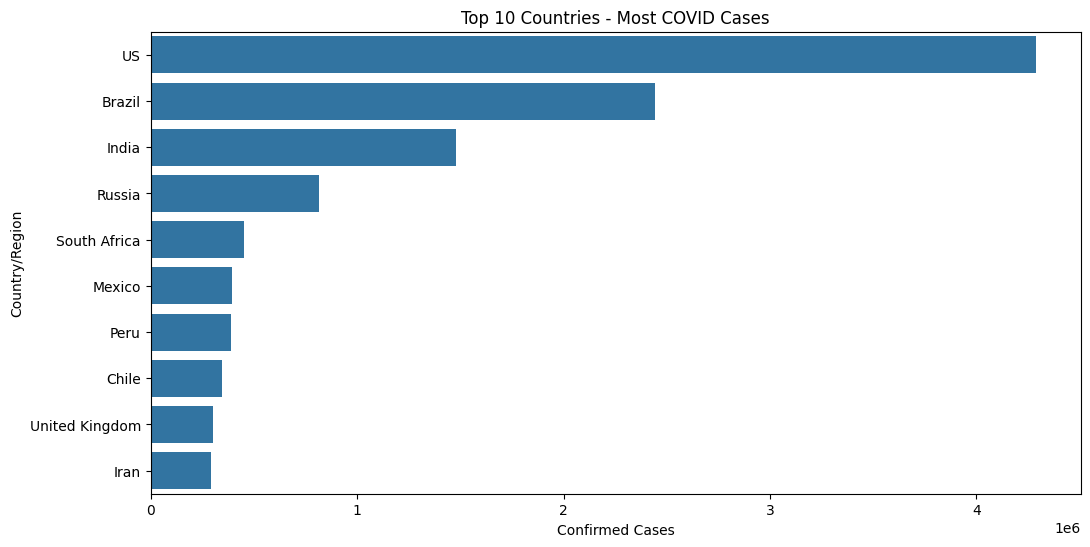

In [ ]:
top10 = country.nlargest(10, 'Confirmed')

plt.figure(figsize=(12,6))
sns.barplot(x='Confirmed', y='Country/Region', data=top10)
plt.title('Top 10 Countries - Most COVID Cases')
plt.xlabel('Confirmed Cases')
plt.show()

/tmp/ipykernel_1745/1864120228.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Deaths', y='Country/Region', data=top10_deaths, palette='Reds_r')


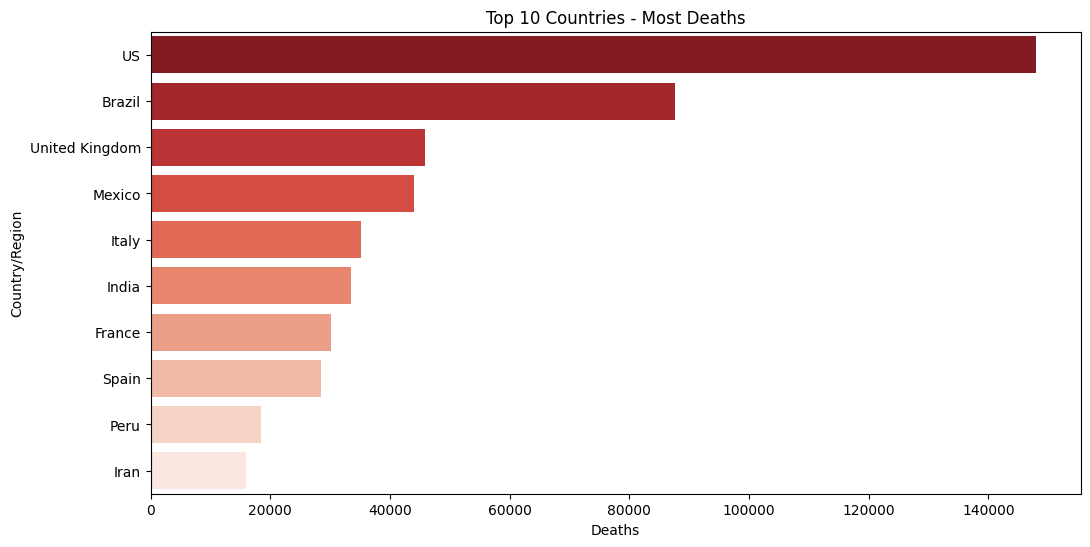

In [ ]:
top10_deaths = country.nlargest(10, 'Deaths')

plt.figure(figsize=(12,6))
sns.barplot(x='Deaths', y='Country/Region', data=top10_deaths, palette='Reds_r')
plt.title('Top 10 Countries - Most Deaths')
plt.show()

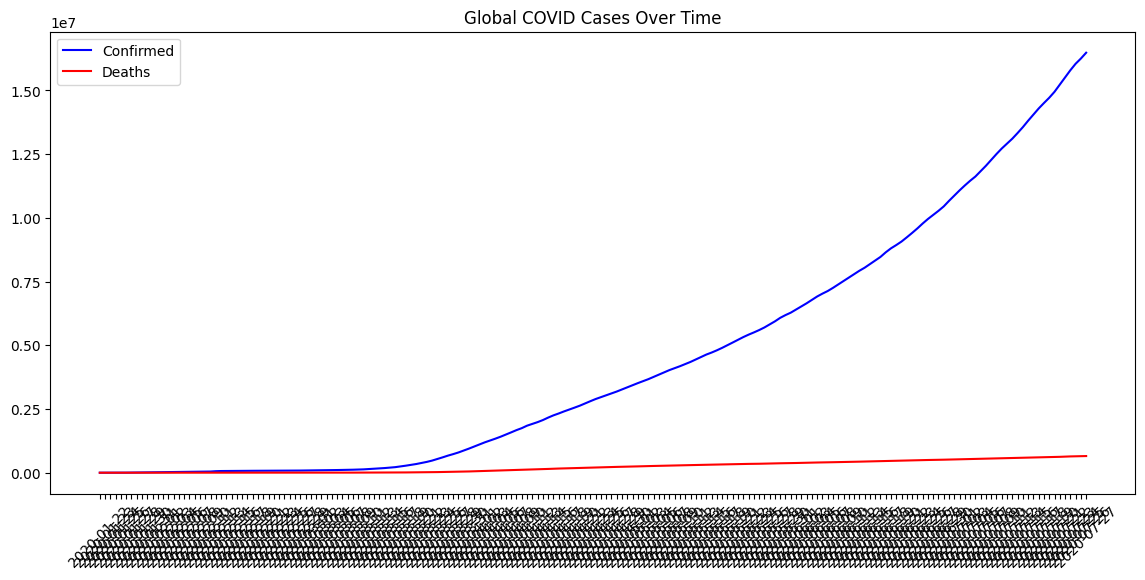

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(daywise['Date'], daywise['Confirmed'], color='blue', label='Confirmed')
plt.plot(daywise['Date'], daywise['Deaths'], color='red', label='Deaths')
plt.title('Global COVID Cases Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [ ]:
daywise.head(10)

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries
0,2020-01-22,555,17,28,510,0,0,0,3.06,5.05,60.71,6
1,2020-01-23,654,18,30,606,99,1,2,2.75,4.59,60.00,8
2,2020-01-24,941,26,36,879,287,8,6,2.76,3.83,72.22,9
3,2020-01-25,1434,42,39,1353,493,16,3,2.93,2.72,107.69,11
4,2020-01-26,2118,56,52,2010,684,14,13,2.64,2.46,107.69,13
5,2020-01-27,2927,82,61,2784,809,26,9,2.80,2.08,134.43,16
6,2020-01-28,5578,131,107,5340,2651,49,46,2.35,1.92,122.43,16
7,2020-01-29,6166,133,125,5908,588,2,18,2.16,2.03,106.40,18
8,2020-01-30,8234,171,141,7922,2068,38,16,2.08,1.71,121.28,20
9,2020-01-31,9927,213,219,9495,1693,42,78,2.15,2.21,97.26,24
